In [11]:
import os
import sys
from pathlib import Path
!pip install lxml
# ===================================================================
# 1) Projektwurzel automatisch finden (Ordner mit bootstrap.py)
# ===================================================================
def find_project_root(start: Path, marker="bootstrap.py"):
    start = start.resolve()
    p = start

    while True:
        if (p / marker).exists():
            return p
        if p.parent == p:
            raise RuntimeError(f"Projektwurzel nicht gefunden (Marker '{marker}').")
        p = p.parent

# Notebook-Verzeichnis
nb_path = Path(os.getcwd())
project_root = find_project_root(nb_path)

print("📁 Projektwurzel:", project_root)

# Arbeitsverzeichnis ändern
os.chdir(project_root)

# Python-Pfad aktualisieren
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# ===================================================================
# 2) Bootstrap importieren
# ===================================================================
import bootstrap

# ===================================================================
# 3) Projekt initialisieren
# ===================================================================
cfg = bootstrap.init(verbose=True)
cfg

📁 Projektwurzel: /Users/jakobkoppermann/Coding/inat_habitat_modeling
🔧 BOOTSTRAP: Lade Konfiguration
📁 Projektwurzel: /Users/jakobkoppermann/Coding/inat_habitat_modeling
📄 default.yaml: /Users/jakobkoppermann/Coding/inat_habitat_modeling/config/default.yaml
📄 local.yaml:   /Users/jakobkoppermann/Coding/inat_habitat_modeling/config/local.yaml
📄 Lade default.yaml: /Users/jakobkoppermann/Coding/inat_habitat_modeling/config/default.yaml
📄 Lade local.yaml: /Users/jakobkoppermann/Coding/inat_habitat_modeling/config/local.yaml
  ✔ YAMLs gemerged.
🌍 Region: berlin → [12.7, 52.0, 14.3, 53.0]
🧬 Species: macrolepiota_procera → Macrolepiota procera
🌍 Region WGS84: [12.7, 52.0, 14.3, 53.0]
   → UTM-CRS: EPSG:32633
   → bbox_utm: [342113.975565586, 5763535.991402085, 453023.0609648683, 5872499.713667939]
   ✔ Region → GEE synchronisiert

📂 Speziespfade:
   • output_dir_species: /Volumes/Data/iNaturalist/outputs/macrolepiota_procera
   • features_dir_species: /Volumes/Data/iNaturalist/features/macrol

{'project': {'name': 'inat-habitat-modeling',
  'author': 'Jakob Koeppen',
  'description': 'Modellierung von Habitaten basierend auf iNaturalist + EO-Daten'},
 'paths': {'weather_dir': '/Volumes/Data/iNaturalist/weather',
  'base_data_dir': '/Volumes/Data/iNaturalist',
  'output_dir_species': '/Volumes/Data/iNaturalist/outputs/macrolepiota_procera',
  'features_dir_species': '/Volumes/Data/iNaturalist/features/macrolepiota_procera',
  'temp_dir_species': '/Volumes/Data/iNaturalist/temp/macrolepiota_procera'},
 'regions': {'berlin': {'bbox_wgs84': [12.7, 52.0, 14.3, 53.0],
   'utm_crs': 'EPSG:32633',
   'bbox_utm': [342113.975565586,
    5763535.991402085,
    453023.0609648683,
    5872499.713667939]},
  'brandenburg': {'bbox_wgs84': [11.7, 51.6, 14.8, 53.6],
   'utm_crs': 'EPSG:32633'}},
 'species': {'macrolepiota_procera': {'id': 63401,
   'name': 'Macrolepiota procera',
   'label': 'pilz'},
  'parus_major': {'id': 203153, 'name': 'Parus major', 'label': 'meise'}},
 'defaults': {'re

In [27]:
# ---------------------------------------------
# Standard-Imports
# ---------------------------------------------
from pathlib import Path

# Earth Engine
import ee

# Sicherstellen, dass GEE initialisiert ist
try:
    ee.Initialize()
    print("✅ Earth Engine initialisiert")
except Exception as e:
    print("❌ Earth Engine nicht initialisiert:", e)

✅ Earth Engine initialisiert


In [28]:
# ---------------------------------------------
# ERA5-Land Weather Pipeline
# ---------------------------------------------
from pipe.weather.era5_monthly import (
    export_year_to_drive,
    export_batch_to_drive,
)

In [29]:
# ---------------------------------------------
# Region & Jahre aus Projektkonfiguration
# ---------------------------------------------

# BBox aus cfg (WGS84: [W, S, E, N])
bbox = cfg["region"]["bbox_wgs84"]

# GEE-Geometrie
region = ee.Geometry.Rectangle(bbox)

# Jahre aus default.yaml
YEARS = cfg["export"]["years"]

print("🌍 Region (bbox):", bbox)
print("📅 Jahre:", YEARS)

🌍 Region (bbox): [12.7, 52.0, 14.3, 53.0]
📅 Jahre: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [30]:
# ---------------------------------------------
# TEST: einzelnes Jahr exportieren
# ---------------------------------------------
test_year = YEARS[0]

task = export_year_to_drive(
    year=test_year,
    region=region,
    out_name=f"weather_{test_year}",
)

print(f"⬆️ Export gestartet für {test_year}")

⬆️ Export gestartet für 2017


In [31]:
# ---------------------------------------------
# Batch-Export: alle Jahre
# ---------------------------------------------
tasks = export_batch_to_drive(
    years=YEARS,
    region=region,
    name_prefix="weather",
)

print(f"🚀 {len(tasks)} Exports gestartet")

⬆️ started export: weather_2017
⬆️ started export: weather_2018
⬆️ started export: weather_2019
⬆️ started export: weather_2020
⬆️ started export: weather_2021
⬆️ started export: weather_2022
⬆️ started export: weather_2023
⬆️ started export: weather_2024
🚀 8 Exports gestartet


In [44]:
import ee
import geemap

# --------------------------------------------------
# Init Earth Engine
# --------------------------------------------------
ee.Initialize()

# --------------------------------------------------
# Deutschland-Geometrie
# --------------------------------------------------
countries = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017")
germany = countries.filter(ee.Filter.eq("country_na", "Germany"))
region = germany.geometry()

# --------------------------------------------------
# ERA5-Land Monthly
# --------------------------------------------------
era5 = ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY")

# --------------------------------------------------
# Funktion: Juni-Wetter eines Jahres
# --------------------------------------------------
def june_weather(year):
    img = (
        era5
        .filter(ee.Filter.calendarRange(year, year, "year"))
        .filter(ee.Filter.calendarRange(6, 6, "month"))
        .first()
    )

    precip = (
        img.select("total_precipitation")
        .multiply(1000)   # m → mm  (und sonst nichts!)
        .rename("precip_mm")
    )

    temp = (
        img.select("temperature_2m")
        .subtract(273.15)
        .rename("temp_c")
    )

    return precip.addBands(temp)

# --------------------------------------------------
# Karte
# --------------------------------------------------
Map = geemap.Map()

years = [2018, 2019, 2020, 2022]

for y in years:
    img = june_weather(y)
    
    Map.addLayer(
        img.select("precip_mm"),
        {
            "min": 0.5,   # mm/Tag
            "max": 5,
            "palette": ["#f7fbff", "#c6dbef", "#6baed6", "#2171b5", "#08306b"],
        },
        f"June precip (mm/day) {y}",
        False
    )
    
    Map.addLayer(
        img.select("temp_c"),
        {
            "min": 10,
            "max": 22,
            "palette": ["#2c7bb6", "#abd9e9", "#ffffbf", "#fdae61", "#d7191c"],
        },
        f"June Temp {y}",
        False
    )

Map.centerObject(region, 5)
Map

Map(center=[51.04952573474018, 10.372575736879764], controls=(WidgetControl(options=['position', 'transparent_…

In [51]:
from pipe.weather.build_grid_20km import main as build_grid_20km

In [52]:
build_grid_20km()

🌍 Loading Germany geometry …
🔲 Building 20 km grid …
🆔 Assigning grid IDs …
💾 Writing grid to /Volumes/Data/iNaturalist/weather/grid/grid_20km_DE.gpkg
✅ Done. Cells: 1019


In [53]:
import geopandas as gpd

grid_path = Path("/Volumes/Data/iNaturalist/weather/grid/grid_20km_DE.gpkg")
grid = gpd.read_file(grid_path)

print("CRS:", grid.crs)
print("Cells:", len(grid))
grid.head()

CRS: EPSG:3035
Cells: 1019


,grid_id,geometry
0,DE20_000000,"MULTIPOLYGON (((4150297.072 2724183.631, 41502..."
1,DE20_000001,"MULTIPOLYGON (((4150297.072 2744183.631, 41502..."
2,DE20_000002,"MULTIPOLYGON (((4150297.072 2764183.631, 41502..."
3,DE20_000003,"MULTIPOLYGON (((4150297.072 2724183.631, 41702..."
4,DE20_000004,"MULTIPOLYGON (((4170297.072 2724183.631, 41842..."


In [3]:
!pip install pygbif

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [pygbif]


In [3]:
import os

os.environ["GBIF_USER"] = "jkoeppens"
os.environ["GBIF_PWD"] = "?@Z>N#kW*#Sb'6H"
os.environ["GBIF_EMAIL"] = "jakob.koeppens@gmail.com"

print(os.environ["GBIF_USER"])
print(os.environ["GBIF_EMAIL"])

jkoeppens
jakob.koeppens@gmail.com


In [10]:
import pandas as pd

gbif_path = "/Volumes/Data/iNaturalist/gbif/0017039-260108223611665.csv"

# RICHTIG: Tab-separiert einlesen
df = pd.read_csv(gbif_path, sep="\t", low_memory=False)

print("📊 Spaltenanzahl:", df.shape[1])
print("📂 Spaltennamen:")
for c in df.columns:
    print(" -", c)

df.head()

📊 Spaltenanzahl: 50
📂 Spaltennamen:
 - gbifID
 - datasetKey
 - occurrenceID
 - kingdom
 - phylum
 - class
 - order
 - family
 - genus
 - species
 - infraspecificEpithet
 - taxonRank
 - scientificName
 - verbatimScientificName
 - verbatimScientificNameAuthorship
 - countryCode
 - locality
 - stateProvince
 - occurrenceStatus
 - individualCount
 - publishingOrgKey
 - decimalLatitude
 - decimalLongitude
 - coordinateUncertaintyInMeters
 - coordinatePrecision
 - elevation
 - elevationAccuracy
 - depth
 - depthAccuracy
 - eventDate
 - day
 - month
 - year
 - taxonKey
 - speciesKey
 - basisOfRecord
 - institutionCode
 - collectionCode
 - catalogNumber
 - recordNumber
 - identifiedBy
 - dateIdentified
 - license
 - rightsHolder
 - recordedBy
 - typeStatus
 - establishmentMeans
 - lastInterpreted
 - mediaType
 - issue


,gbifID,datasetKey,occurrenceID,kingdom,phylum,class,order,family,genus,species,...,identifiedBy,dateIdentified,license,rightsHolder,recordedBy,typeStatus,establishmentMeans,lastInterpreted,mediaType,issue
0,4400415699,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/17899...,Plantae,Tracheophyta,Magnoliopsida,Ranunculales,Ranunculaceae,Actaea,Actaea spicata,...,hypochaeris,2023-08-18T15:23:09,CC_BY_NC_4_0,hypochaeris,hypochaeris,NaN,NaN,2026-01-08T22:02:54.560Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
1,2294589224,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/29165636,Animalia,Mollusca,Gastropoda,Stylommatophora,Helicidae,Cepaea,Cepaea nemoralis,...,Janka,2019-07-20T12:45:01,CC0_1_0,Peter Gabler,Peter Gabler,NaN,NaN,2026-01-08T22:31:49.025Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
2,4851942462,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/21182...,Fungi,Ascomycota,Lecanoromycetes,Lecanorales,Parmeliaceae,Hypogymnia,Hypogymnia tubulosa,...,Robert Lücking,2024-04-29T20:20:03,CC_BY_NC_4_0,Robert Lücking,Robert Lücking,NaN,NaN,2026-01-08T22:07:35.522Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
3,4863622336,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/21352...,Plantae,Tracheophyta,Liliopsida,Asparagales,Asparagaceae,Polygonatum,Polygonatum multiflorum,...,Leana,2024-05-04T21:31:26,CC_BY_NC_4_0,Leana,Leana,NaN,NaN,2026-01-08T22:07:44.385Z,StillImage;StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
4,5932311221,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/26100...,Fungi,Basidiomycota,Agaricomycetes,Agaricales,Mycenaceae,Panellus,Panellus stipticus,...,R. Ziebarth,2025-02-08T15:36:14,CC_BY_NC_4_0,R. Ziebarth,R. Ziebarth,NaN,NaN,2026-01-08T22:14:55.059Z,StillImage;StillImage;StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...


NameError: name 'df' is not defined

In [10]:
from pygbif import occurrences as occ

INAT_DATASET_KEY = "50c9509d-22c7-4a22-a47d-8c48425ef4a7"

download_key = occ.download(
    [
        f"datasetKey = {INAT_DATASET_KEY}",
        "country = DE",
        "hasCoordinate = true",
        "year in [2017,2018,2019,2020,2021,2022,2023,2024]",
    ],
    format="SIMPLE_CSV",
)

print("Download key:", download_key)
print("Status URL:")
print(f"https://www.gbif.org/occurrence/download/{download_key}")

INFO:Your download key is 0017039-260108223611665


Download key: ('0017039-260108223611665', {'creator': 'jkoeppens', 'notification_address': ['jakob.koeppens@gmail.com'], 'sendNotification': True, 'predicate': {'type': 'and', 'predicates': [{'type': 'equals', 'key': 'DATASET_KEY', 'value': '50c9509d-22c7-4a22-a47d-8c48425ef4a7'}, {'type': 'equals', 'key': 'COUNTRY', 'value': 'DE'}, {'type': 'equals', 'key': 'HAS_COORDINATE', 'value': 'true'}, {'type': 'in', 'key': 'YEAR', 'values': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]}]}, 'format': 'SIMPLE_CSV'})
Status URL:
https://www.gbif.org/occurrence/download/('0017039-260108223611665', {'creator': 'jkoeppens', 'notification_address': ['jakob.koeppens@gmail.com'], 'sendNotification': True, 'predicate': {'type': 'and', 'predicates': [{'type': 'equals', 'key': 'DATASET_KEY', 'value': '50c9509d-22c7-4a22-a47d-8c48425ef4a7'}, {'type': 'equals', 'key': 'COUNTRY', 'value': 'DE'}, {'type': 'equals', 'key': 'HAS_COORDINATE', 'value': 'true'}, {'type': 'in', 'key': 'YEAR', 'values': [2017, 20

In [11]:
import pandas as pd

CSV_PATH = "/Volumes/Data/iNaturalist/weather/gbif/raw/0017039-260108223611665.csv"

df_head = pd.read_csv(
    CSV_PATH,
    sep="\t",
    nrows=5,
    low_memory=False
)

df_head

,gbifID,datasetKey,occurrenceID,kingdom,phylum,class,order,family,genus,species,...,identifiedBy,dateIdentified,license,rightsHolder,recordedBy,typeStatus,establishmentMeans,lastInterpreted,mediaType,issue
0,4400415699,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/17899...,Plantae,Tracheophyta,Magnoliopsida,Ranunculales,Ranunculaceae,Actaea,Actaea spicata,...,hypochaeris,2023-08-18T15:23:09,CC_BY_NC_4_0,hypochaeris,hypochaeris,NaN,NaN,2026-01-08T22:02:54.560Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
1,2294589224,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/29165636,Animalia,Mollusca,Gastropoda,Stylommatophora,Helicidae,Cepaea,Cepaea nemoralis,...,Janka,2019-07-20T12:45:01,CC0_1_0,Peter Gabler,Peter Gabler,NaN,NaN,2026-01-08T22:31:49.025Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
2,4851942462,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/21182...,Fungi,Ascomycota,Lecanoromycetes,Lecanorales,Parmeliaceae,Hypogymnia,Hypogymnia tubulosa,...,Robert Lücking,2024-04-29T20:20:03,CC_BY_NC_4_0,Robert Lücking,Robert Lücking,NaN,NaN,2026-01-08T22:07:35.522Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
3,4863622336,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/21352...,Plantae,Tracheophyta,Liliopsida,Asparagales,Asparagaceae,Polygonatum,Polygonatum multiflorum,...,Leana,2024-05-04T21:31:26,CC_BY_NC_4_0,Leana,Leana,NaN,NaN,2026-01-08T22:07:44.385Z,StillImage;StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
4,5932311221,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/26100...,Fungi,Basidiomycota,Agaricomycetes,Agaricales,Mycenaceae,Panellus,Panellus stipticus,...,R. Ziebarth,2025-02-08T15:36:14,CC_BY_NC_4_0,R. Ziebarth,R. Ziebarth,NaN,NaN,2026-01-08T22:14:55.059Z,StillImage;StillImage;StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...


In [2]:
from pipe.weather.build_grid_counts import main
main()

🌍 Loading grid …
🔲 Grid cells: 1019
📦 Starting GBIF stream …
▶ Chunk 1
▶ Chunk 2
▶ Chunk 3
▶ Chunk 4
▶ Chunk 5
▶ Chunk 6
▶ Chunk 7
▶ Chunk 8
▶ Chunk 9
▶ Chunk 10
▶ Chunk 11
▶ Chunk 12
▶ Chunk 13
🧮 Combining chunks …
💾 Writing /Volumes/Data/iNaturalist/weather/inat/processed/grid_counts.parquet
✅ M3 complete
Rows: 58990


In [3]:
import pandas as pd

df = pd.read_parquet(
    "/Volumes/Data/iNaturalist/weather/inat/processed/grid_counts.parquet"
)

df[["n_parasol", "n_controls"]].sum()

n_parasol        1327
n_controls    2409400
dtype: int64

In [4]:
df.groupby("year")["n_parasol"].sum()

year
2017     32
2018     17
2019    132
2020    208
2021    160
2022    306
2023    237
2024    235
Name: n_parasol, dtype: int64

In [5]:
(df.groupby("grid_id")["n_parasol"].sum() > 0).sum()

np.int64(475)

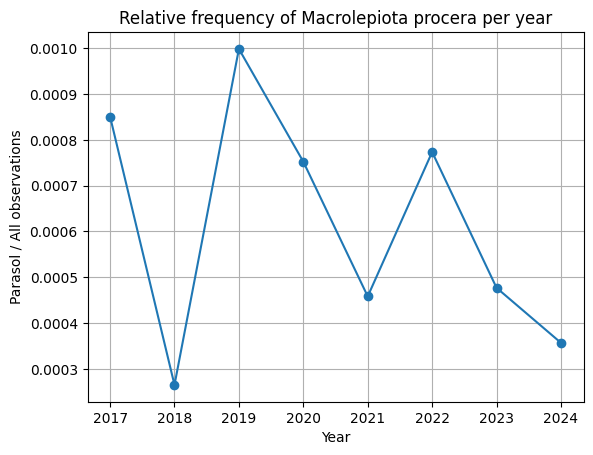

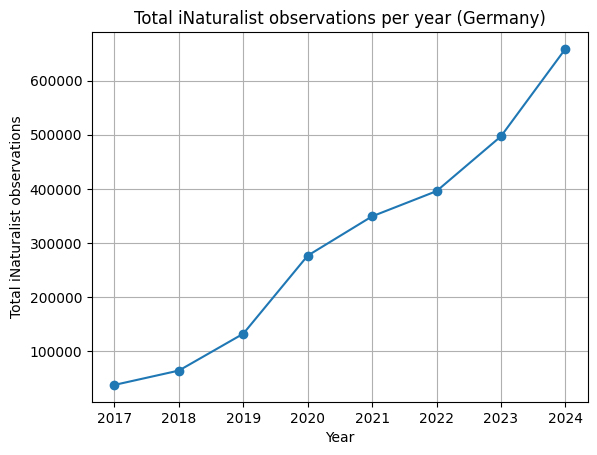

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Load data
# --------------------------------------------------
df = pd.read_parquet(
    "/Volumes/Data/iNaturalist/weather/inat/processed/grid_counts.parquet"
)

# --------------------------------------------------
# Aggregate per year
# --------------------------------------------------
yearly = (
    df.groupby("year")[["n_parasol", "n_controls", "n_total"]]
    .sum()
    .sort_index()
)

# Anteil Parasol an allen Beobachtungen
yearly["parasol_ratio"] = yearly["n_parasol"] / yearly["n_total"]

# --------------------------------------------------
# Plot 1: Anteil Parasol pro Jahr
# --------------------------------------------------
plt.figure()
plt.plot(
    yearly.index,
    yearly["parasol_ratio"],
    marker="o"
)
plt.xlabel("Year")
plt.ylabel("Parasol / All observations")
plt.title("Relative frequency of Macrolepiota procera per year")
plt.grid(True)
plt.show()

# --------------------------------------------------
# Plot 2: Gesamtzahl Beobachtungen pro Jahr
# --------------------------------------------------
plt.figure()
plt.plot(
    yearly.index,
    yearly["n_total"],
    marker="o"
)
plt.xlabel("Year")
plt.ylabel("Total iNaturalist observations")
plt.title("Total iNaturalist observations per year (Germany)")
plt.grid(True)
plt.show()

In [ ]:
from pipe.weather.m4_yearly_weather_de import main

main()

⛅ Processing year 2017
⛅ Processing year 2018
⛅ Processing year 2019
⛅ Processing year 2020
⛅ Processing year 2021
⛅ Processing year 2022
⛅ Processing year 2023
⛅ Processing year 2024


,precip_ann,precip_jul_aug,precip_may_jun,precip_sep_oct,temp_ann,temp_jul_aug,temp_may_jun,temp_sep_oct
year,,,,,,,,
2017,0.950930,0.215783,0.161724,0.163484,282.779023,291.425801,289.130293,285.459133
2018,0.657950,0.083901,0.109980,0.076459,283.895571,293.968066,290.306031,286.777683
2019,0.847977,0.138517,0.149224,0.165460,283.595001,292.636247,288.732349,286.172236
2020,0.817517,0.154380,0.150966,0.140512,283.775878,292.365894,287.836139,286.160384
2021,0.983938,0.237766,0.232413,0.104783,282.322787,290.690309,287.917929,285.945128
2022,0.821139,0.111043,0.134017,0.179095,283.738445,293.146041,289.583363,286.446081
2023,1.032198,0.224761,0.103563,0.139249,283.878989,291.961773,289.127193,288.257409
2024,1.000319,0.160855,0.223000,0.177072,284.170137,292.786706,289.078957,286.834657


In [ ]:
import pandas as pd

weather = pd.read_parquet(
    "/Volumes/Data/iNaturalist/weather/derived/weather_grid_year_m5.parquet"
)

weather.head()

🌦️ Processing year 2017
💾 checkpoint written (1019 rows)
🌦️ Processing year 2018
💾 checkpoint written (2038 rows)
🌦️ Processing year 2019
💾 checkpoint written (3057 rows)
🌦️ Processing year 2020
💾 checkpoint written (4076 rows)
🌦️ Processing year 2021
💾 checkpoint written (5095 rows)
🌦️ Processing year 2022
💾 checkpoint written (6114 rows)
🌦️ Processing year 2023
💾 checkpoint written (7133 rows)
🌦️ Processing year 2024
💾 checkpoint written (8152 rows)
✅ M5 complete


ImportError: cannot import name 'main' from 'pipe.weather.m5_weather_grid_year_de' (/Users/jakobkoppermann/Coding/inat_habitat_modeling/pipe/weather/m5_weather_grid_year_de.py)

In [2]:
from pipe.weather.m4b_weather_grid_monthly_de import *

🌦 Processing year 2023
💾 checkpoint written (1019 rows)
🌦 Processing year 2024
💾 checkpoint written (2038 rows)
✅ M4b complete (monthly)


📥 Loading weather data
📥 Loading counts

=== STRUCTURE ===
Shape: (8152, 26)
Columns:
['grid_id', 'precip_m01', 'precip_m02', 'precip_m03', 'precip_m04', 'precip_m05', 'precip_m06', 'precip_m07', 'precip_m08', 'precip_m09', 'precip_m10', 'precip_m11', 'precip_m12', 'temp_m01', 'temp_m02', 'temp_m03', 'temp_m04', 'temp_m05', 'temp_m06', 'temp_m07', 'temp_m08', 'temp_m09', 'temp_m10', 'temp_m11', 'temp_m12', 'year']
✔ All monthly columns present

=== ROWS PER YEAR ===
year
2017    1019
2018    1019
2019    1019
2020    1019
2021    1019
2022    1019
2023    1019
2024    1019
dtype: int64

=== MISSING VALUES (fraction) ===
temp_m01      0.013739
temp_m12      0.013739
temp_m10      0.013739
temp_m09      0.013739
temp_m08      0.013739
temp_m07      0.013739
temp_m06      0.013739
temp_m05      0.013739
temp_m04      0.013739
temp_m03      0.013739
temp_m02      0.013739
precip_m01    0.013739
precip_m12    0.013739
precip_m11    0.013739
precip_m10    0.013739
dtype: float64

=== TEMPERA

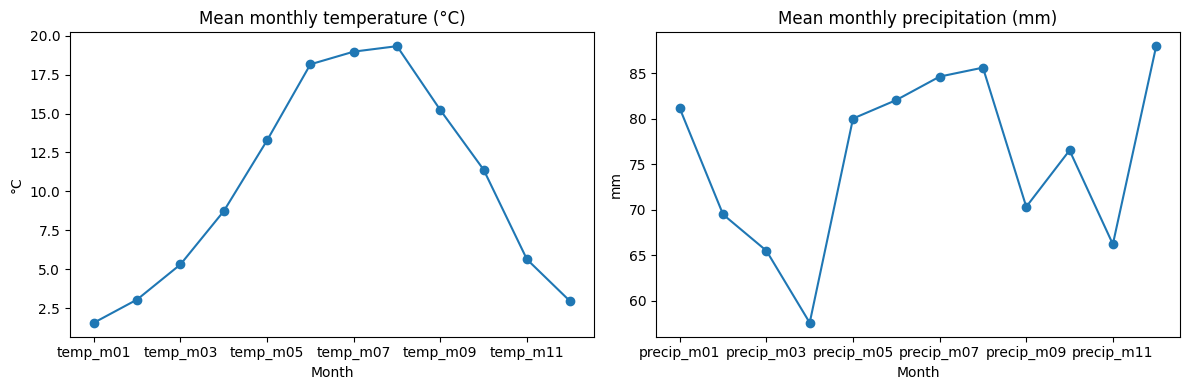


=== SPATIAL VARIANCE ===
temp_m01 std per year:
year
2017    2.240752
2018    1.248607
2019    1.723585
2020    1.776971
2021    1.579137
2022    1.721116
2023    1.511040
2024    1.283404
Name: temp_m01, dtype: float64
temp_m07 std per year:
year
2017    1.152513
2018    1.338864
2019    1.160497
2020    1.313310
2021    1.311003
2022    1.273028
2023    1.270528
2024    1.095512
Name: temp_m07, dtype: float64

=== JOIN WITH COUNTS ===
Joined shape: (58990, 30)
Rows per year after join:
year
2017     3157
2018     4109
2019     5974
2020     7872
2021     8795
2022     9258
2023     9659
2024    10166
dtype: int64

=== BASIC TARGET STATS ===
               year         month     n_parasol       n_total    n_controls  \
count  58990.000000  58990.000000  58990.000000  58990.000000  58990.000000   
mean    2021.242397      6.642448      0.022495     40.866706     40.844211   
std        2.079890      3.039436      0.199983    115.332821    115.312636   
min     2017.000000      1.00000

In [5]:
from pipe.weather.debug_weather_monthly import *

In [17]:
from pipe.weather.m4c_merge_weather_counts_monthly import *

🔗 M4c – merge monthly weather + counts
📥 Loading data
   weather rows: 8,152
   counts rows : 58,990
🔄 Reshaping weather to monthly (long)
   weather_long rows: 96,480
🔗 Merging
✔ merged rows: 58,582

=== MERGED STRUCTURE ===
grid_id        object
year            int64
month           int64
n_parasol       int64
n_total         int64
n_controls      int64
precip        float64
temp          float64
dtype: object

Rows per year:
year
2017     3143
2018     4087
2019     5931
2020     7822
2021     8737
2022     9190
2023     9588
2024    10084
dtype: int64

Missing values (fraction):
temp      0.0
precip    0.0
dtype: float64

✅ M4c complete
📁 Written to: /Volumes/Data/iNaturalist/weather/derived/merged_grid_weather_counts_monthly.parquet


In [18]:
# läuft direkt beim Import durch (weil es ein run-script ist)
import importlib
import pipe.weather.m5_models_parasol_monthly_ab as m5
importlib.reload(m5)

🚀 START M5 – Parasol monthly models A vs B
📥 Loading merged data
   rows: 58,582
   years: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
   months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
✔ Rows after MIN_TOTAL filter: 29,232
   n_parasol total: 1158
   n_total total  : 2303830

📐 Fitting full Model A (month-only)


/Users/jakobkoppermann/Coding/inat_habitat_modeling/venv/lib/python3.9/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/Users/jakobkoppermann/Coding/inat_habitat_modeling/venv/lib/python3.9/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


   done. llf: -3547.1197439955317 aic: 7118.2394879910635

📐 Fitting full Model B (month + weather)
   done. llf: -3523.166584351128 aic: 7074.333168702256

🔁 LOYO (leave-one-year-out) for A and B


/Users/jakobkoppermann/Coding/inat_habitat_modeling/venv/lib/python3.9/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/Users/jakobkoppermann/Coding/inat_habitat_modeling/venv/lib/python3.9/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/Users/jakobkoppermann/Coding/inat_habitat_modeling/venv/lib/python3.9/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/Users/jakobkoppermann/Coding/inat_habitat_modeling/venv/lib/python3.9/site-packages/statsmodels/genmod/families

✔ LOYO written: /Volumes/Data/iNaturalist/weather/models/m5_parasol_monthly_ab/loyo.parquet
✔ coefficients written
✔ summary written: /Volumes/Data/iNaturalist/weather/models/m5_parasol_monthly_ab/summary.parquet

=== QUICK READOUT ===
                                                                0
n_rows                                                      29232
n_grids                                                       977
years                     2017,2018,2019,2020,2021,2022,2023,2024
min_total_filter                                               10
llf_A                                                -3547.119744
aic_A                                                 7118.239488
llf_B                                                -3523.166584
aic_B                                                 7074.333169
delta_ll_B_minus_A                                       23.95316
delta_aic_A_minus_B                                     43.906319
loyo_mean_corr_A                      

/Users/jakobkoppermann/Coding/inat_habitat_modeling/venv/lib/python3.9/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/Users/jakobkoppermann/Coding/inat_habitat_modeling/venv/lib/python3.9/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


   done. llf: -3523.166584351128 aic: 7074.333168702256

🔁 LOYO (leave-one-year-out) for A and B


/Users/jakobkoppermann/Coding/inat_habitat_modeling/venv/lib/python3.9/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/Users/jakobkoppermann/Coding/inat_habitat_modeling/venv/lib/python3.9/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/Users/jakobkoppermann/Coding/inat_habitat_modeling/venv/lib/python3.9/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/Users/jakobkoppermann/Coding/inat_habitat_modeling/venv/lib/python3.9/site-packages/statsmodels/genmod/families

✔ LOYO written: /Volumes/Data/iNaturalist/weather/models/m5_parasol_monthly_ab/loyo.parquet
✔ coefficients written
✔ summary written: /Volumes/Data/iNaturalist/weather/models/m5_parasol_monthly_ab/summary.parquet

=== QUICK READOUT ===
                                                                0
n_rows                                                      29232
n_grids                                                       977
years                     2017,2018,2019,2020,2021,2022,2023,2024
min_total_filter                                               10
llf_A                                                -3547.119744
aic_A                                                 7118.239488
llf_B                                                -3523.166584
aic_B                                                 7074.333169
delta_ll_B_minus_A                                       23.95316
delta_aic_A_minus_B                                     43.906319
loyo_mean_corr_A                      

<module 'pipe.weather.m5_models_parasol_monthly_ab' from '/Users/jakobkoppermann/Coding/inat_habitat_modeling/pipe/weather/m5_models_parasol_monthly_ab.py'>

In [21]:
from pipe.weather.m7a_build_parasol_fall_features import *

🚀 M7a – building fall Parasol feature table
📥 Loaded rows: 58,582
Years: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
🍂 Fall rows: 6,532
🌱 Spring–summer feature rows: 7,464
✅ Final rows: 6,418
📦 Written: /Volumes/Data/iNaturalist/weather/derived/m7_features_parasol_fall_from_spring_summer.parquet
🏁 M7a complete


In [32]:
from pipe.weather.m7b_glm_parasol_fall import *

🚀 START M7b – GLM fall parasol
📥 Loading data
✔ Rows after filter: 4,208
✔ Grids: 929
✔ Years: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
📐 Fitting Negative Binomial GLM
                 Generalized Linear Model Regression Results                  
Dep. Variable:            y_n_parasol   No. Observations:                 4208
Model:                            GLM   Df Residuals:                     4191
Model Family:        NegativeBinomial   Df Model:                           16
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2324.9
Date:                Sun, 18 Jan 2026   Deviance:                       2391.0
Time:                        12:39:11   Pearson chi2:                 6.15e+03
No. Iterations:                     8   Pseudo R-squ. (CS):            0.04534
Covariance Type:            nonro

/Users/jakobkoppermann/Coding/inat_habitat_modeling/venv/lib/python3.9/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [33]:
from pipe.weather.m8_xgb_parasol_fall import *

🚀 START M8 – XGBoost Parasol (fall)
✔ Rows: 4,208
✔ Years: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
🔁 LOYO evaluation
   test_year   r2_rate  n_obs
0       2017 -0.666330    113
1       2018 -3.227870    195
2       2019 -0.026239    357
3       2020 -0.832455    580
4       2021 -0.066964    675
5       2022 -0.080763    682
6       2023 -0.829267    780
7       2024 -1.323658    826
✔ Mean R²: -0.882
📐 Fitting final model
✔ Model written: /Volumes/Data/iNaturalist/weather/models/m8_xgb_parasol_fall/xgb_model.json
=== TOP FEATURES ===
       feature  importance
12    temp_m05    0.001371
14    temp_m07    0.001198
7   precip_m08    0.001109
11    temp_m04    0.001053
13    temp_m06    0.001033
6   precip_m07    0.001019
5   precip_m06    0.000954
3   precip_m04    0.000954
4   precip_m05    0.000949
15    temp_m08    0.000922
10    temp_m03    0.000865
2   precip_m03    0.000781
✅ M8 complete
📁 Out

In [34]:
from pipe.weather.m9_seasonality_weekly import *

🚀 START M9 – weekly seasonality
⚠️ No week column found – approximating from month
✔ Rows: 96
Weeks: [np.int64(4), np.int64(8), np.int64(12), np.int64(16), np.int64(20), np.int64(24), np.int64(28), np.int64(32), np.int64(36), np.int64(40), np.int64(44), np.int64(48)]
                 Generalized Linear Model Regression Results                  
Dep. Variable:              n_parasol   No. Observations:                   96
Model:                            GLM   Df Residuals:                       89
Model Family:                 Poisson   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -381.24
Date:                Sun, 18 Jan 2026   Deviance:                       569.74
Time:                        13:01:18   Pearson chi2:                     654.
No. Iterations:                    10   Pseudo R-squ. (CS):              1.000
Covariance Type:     

In [40]:
from pipe.weather.M10a_weekly_weather_grid import main
main()

🌍 Loading grid …
🔲 Grid cells: 1019
🌐 Building EE grid FeatureCollection …

📅 YEAR 2017
   weeks: 53
   🧊 week 01: 2017-01-01 → 2017-01-08
      💾 checkpoint rows: 1,019
   🧊 week 02: 2017-01-08 → 2017-01-15
      💾 checkpoint rows: 2,038
   🧊 week 03: 2017-01-15 → 2017-01-22
      💾 checkpoint rows: 3,057
   🧊 week 04: 2017-01-22 → 2017-01-29
      💾 checkpoint rows: 4,076
   🧊 week 05: 2017-01-29 → 2017-02-05
      💾 checkpoint rows: 5,095
   🧊 week 06: 2017-02-05 → 2017-02-12
      💾 checkpoint rows: 6,114
   🧊 week 07: 2017-02-12 → 2017-02-19
      💾 checkpoint rows: 7,133
   🧊 week 08: 2017-02-19 → 2017-02-26
      💾 checkpoint rows: 8,152
   🧊 week 09: 2017-02-26 → 2017-03-05
      💾 checkpoint rows: 9,171
   🧊 week 10: 2017-03-05 → 2017-03-12
      💾 checkpoint rows: 10,190
   🧊 week 11: 2017-03-12 → 2017-03-19
      💾 checkpoint rows: 11,209
   🧊 week 12: 2017-03-19 → 2017-03-26
      💾 checkpoint rows: 12,228
   🧊 week 13: 2017-03-26 → 2017-04-02
      💾 checkpoint rows: 13,24